# Part A :- Concept Application

# Comprehensive ML Cheat Sheet Notebook

---

## Import Libraries

---

In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans

from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB



## Load Dataset
---


We use Breast Cancer dataset because:

- useful for binary classification
- consists of clean tabular data
- widely used benchmark

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

## Algorithm Cards

---

## Logistic Regression

### Description

Logistic Regression is a simple linear classification algorithm used when the relationship between features and target is mostly linear. It works well when interpretability matters and provides probability outputs.
Logistic Regression is a simple linear classification algorithm used when the relationship between features and target is mostly linear. It works well when interpretability matters and provides probability outputs. Logistic Regression is a widely used algorithm for classification problems and is often used as a baseline model for comparison with more complex models.

### When to Use

- Baseline model
- Linear problems
- Need explainability

### Key Hyperparameters

- C
- penalty
- solver

### Pros

- Fast
- Interpretable
- Stable baseline

### Cons

- Weak on nonlinear data

In [4]:
lr = LogisticRegression(max_iter=10000)
lr.fit(X, y)
pred = lr.predict(X)
accracy = lr.score(X, y)
print(f"Logistic Regression Accuracy: {accracy*100}%")


Logistic Regression Accuracy: 95.78207381370825%


## Decision Tree

### Description

Decision Trees split data into rules. Easy to visualize and interpret but prone to overfitting if unrestricted.
Decision Trees are a popular choice for tabular data because of their ease of interpretation and robustness to outliers. They work by recursively partitioning the data into smaller subsets based on the values of the input features. Each split is chosen to maximize the information gain, which is a measure of how well the split separates the classes. Decision Trees can be used for both classification and regression tasks, and they have several advantages over other models, such as handling missing values and being robust to outliers. 

### When to Use

- Rule-based interpretation
- Small-medium datasets

### Key Hyperparameters

- max_depth
- min_samples_split

### Pros

- Explainable
- Handles nonlinear patterns

### Cons

- Overfits easily

In [5]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X, y)
pred = dt.predict(X)
accuracy = dt.score(X, y)
print(f"Decision Tree Accuracy: {accuracy*100}%")

Decision Tree Accuracy: 99.47275922671353%


## Random Forest

### Description

Random Forest is a powerful ensemble learning algorithm that combines multiple decision trees to achieve better predictive performance. It works by training multiple decision trees on different subsets of the data and then combining their predictions to produce the final output. This approach helps to reduce overfitting and improve the accuracy of the model. Random Forest is particularly useful when dealing with complex datasets that have a large number of features. Additionally, it provides feature importance scores which can be used to identify the most important features in the dataset.

### When to Use

- Strong general-purpose tabular model

### Key Hyperparameters

- n_estimators
- max_depth

### Pros

- Robust
- Less overfitting

### Cons

- Less interpretable


In [6]:
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X, y)
pred = rf.predict(X)
accuracy = rf.score(X, y)
print(f"Random Forest Accuracy: {accuracy*100}%")

Random Forest Accuracy: 100.0%




## Extra Trees

### Description

Extra Trees is an ensemble learning method for constructing a multiclass classifier from a collection of binary decision trees classifiers. It is similar to the Random Forest classifier, but it can produce better performance due to the correlation between the trees.
Extra Trees adds more randomness than Random Forest by choosing random split points.

### When to Use

- Faster tree ensemble
- Large tabular datasets

### Key Hyperparameters

- n_estimators
- max_depth

### Pros

- Fast
- Strong variance reduction

### Cons

- Less intuitive

In [7]:
et = ExtraTreesClassifier(n_estimators=200)
et.fit(X, y)
pred = et.predict(X)
accuracy = et.score(X, y)
print(f"Extra Trees Accuracy: {accuracy*100}%")

Extra Trees Accuracy: 100.0%


## K-Nearest Neighbors

### Description

KNN predicts based on nearby samples. It depends heavily on scaling.
K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification and regression tasks. It works by finding the k most similar data points to a given input and then using those points to make a prediction. For example, if we want to classify a new data point as either a cat or dog, the KNN algorithm would find the k most similar data points (e.g. images of cats and dogs) and then use those points to make a prediction about the new data point. This algorithm is often used for image and text classification tasks.


### When to Use

- Small datasets
- Local pattern learning

### Key Hyperparameters

- n_neighbors
- metric

### Pros

- Simple
- No training cost

### Cons

- Slow prediction

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)
pred = knn.predict(X)
accuracy = knn.score(X, y)
print(f"KNN Accuracy: {accuracy*100}%")

KNN Accuracy: 94.72759226713534%


## Support Vector Machine

### Description

SVM finds the maximum margin separator between classes. Very powerful on medium-sized datasets.
Support Vector Machines (SVMs) are a type of supervised learning algorithm that can be used for both classification and regression tasks. They work by finding a decision boundary that maximally separates the classes in the feature space. SVMs are particularly useful when dealing with high-dimensional data as they can reduce the dimensionality of the feature space using the kernel trick. This allows SVMs to be more efficient than traditional machine learning algorithms when dealing with large datasets. SVMs are also robust to outliers and noisy data as they use a soft-margin approach to find the decision boundary. This makes SVMs a popular choice for many machine learning tasks.

### When to Use

- High-dimensional data
- Clear class separation

### Key Hyperparameters

- C
- kernel

### Pros

- Strong accuracy
- Margin optimization

### Cons

- Slower on big datasets

In [9]:
svm = SVC(C=1, kernel='rbf')
svm.fit(X, y)
pred = svm.predict(X)
accuracy = svm.score(X, y)
print(f"SVM Accuracy: {accuracy*100:.4f}%")

SVM Accuracy: 92.2671%



## K-Means

### Description

K-Means is an unsupervised clustering algorithm that groups similar points into clusters. It starts by randomly initializing the centroids of the clusters, and then iteratively updates the centroids and the cluster assignments until the algorithm converges. The algorithm uses the Euclidean distance to calculate the similarity between points and the centroids. The algorithm is sensitive to the initial placement of the centroids, and can get stuck in local optima if the initialization is not good. The algorithm is also sensitive to the number of clusters, and requires the number of clusters to be specified in advance.
K-Means is unsupervised clustering. It groups similar points into clusters.

### When to Use

- Clustering
- Segmentation

### Key Hyperparameters

- n_clusters
- init

### Pros

- Fast
- Easy clustering baseline

### Cons

- Needs K predefined

KMeans clusters generated


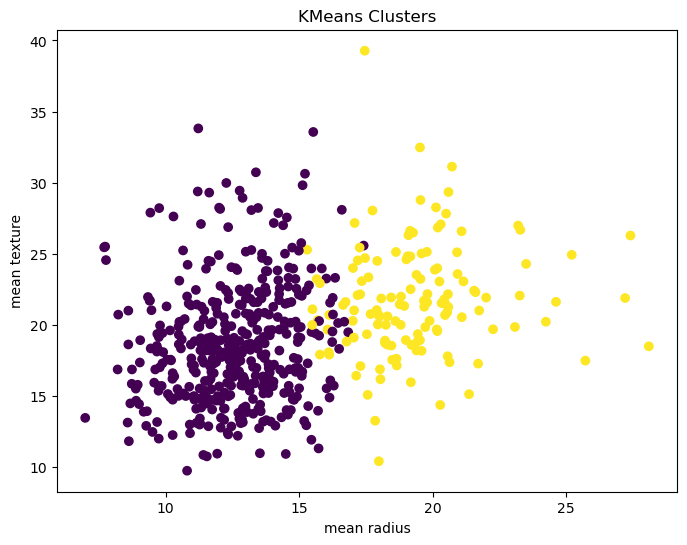

In [10]:
km = KMeans(n_clusters=2)
km.fit(X)
clusters = km.predict(X)

print("KMeans clusters generated")


## Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.title('KMeans Clusters')
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.show()


## XGBoost

### Description

XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible and portable. It is widely used for classification and regression tasks, and is particularly well suited for large scale and sparse data. It is also easy to use with scikit-learn pipelines.
XGBoost is gradient boosting with strong regularization and excellent tabular performance.


### When to Use

- Best tabular accuracy needed

### Key Hyperparameters

- n_estimators
- learning_rate
- max_depth

### Pros

- State-of-the-art
- Regularized

### Cons

- Less interpretable

In [11]:
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05)
xgb.fit(X, y)
pred = xgb.predict(X)
accuracy = xgb.score(X, y)
print(f"XGBoost Accuracy: {accuracy*100}%")

XGBoost Accuracy: 100.0%


## Naive Bayes

### Description

Naive Bayes is a probability based classifier that assumes features are independent. Despite this strong assumption, it performs very well on many real problems, especially text classification and small datasets.
Naive Bayes is a family of probabilistic machine learning models based on Bayes' theorem, with the assumption that each feature is independent of the others. It is commonly used for classification tasks, particularly when the features are categorical. Naive Bayes is simple to implement, and is often used as a baseline for other more complex models. It is also robust to outliers in the data, and can handle missing values. However, it is not as powerful as other models, such as decision trees and random forests, and may not perform as well when there are complex interactions between features.

### When to Use

- Text classification
- Spam detection
- Small datasets
- Fast baseline model
### Key Hyperparameters

- var_smoothing (for Gaussian version)

### Pros
- Extremely fast
- Works well on small data
- Good probabilistic output

### Cons

- Assumes feature independence
- May underperform on complex feature interactions

In [12]:
nb = GaussianNB()
nb.fit(X, y)
pred = nb.predict(X)
accuracy = nb.score(X, y)
print(f"Naive Bayes Accuracy: {accuracy*100}%")

Naive Bayes Accuracy: 94.20035149384886%


# Cross Validation Comparison

In [13]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=500))
    ]),

    'Decision Tree': DecisionTreeClassifier(max_depth=5),

    'Random Forest': RandomForestClassifier(n_estimators=200),

    'Extra Trees': ExtraTreesClassifier(n_estimators=200),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),

    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC())
    ]),
    'Naive Bayes': GaussianNB(),

    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.05)
}

# Run Cross Validation

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = scores.mean()

results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print(results_df)

                 Model  Accuracy
5                  SVM  0.977162
0  Logistic Regression  0.973669
3          Extra Trees  0.964850
4                  KNN  0.963096
7              XGBoost  0.959587
2        Random Forest  0.956094
6          Naive Bayes  0.938534
1        Decision Tree  0.926238


In [15]:
results_df.style.background_gradient(cmap='Blues')

,Model,Accuracy
5,SVM,0.977162
0,Logistic Regression,0.973669
3,Extra Trees,0.964850
4,KNN,0.963096
7,XGBoost,0.959587
2,Random Forest,0.956094
6,Naive Bayes,0.938534
1,Decision Tree,0.926238


 ## K-Means Separate Evaluation

In [16]:
# Evaluate KMeans separately 
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)
print("KMeans clusters generated")

results = cross_val_score(kmeans, X, y, cv=cv, scoring='accuracy')
print(f"KMeans CV Accuracy: {results.mean()*100:.4f}%")

KMeans clusters generated
KMeans CV Accuracy: 55.4184%


## Ranking Plot

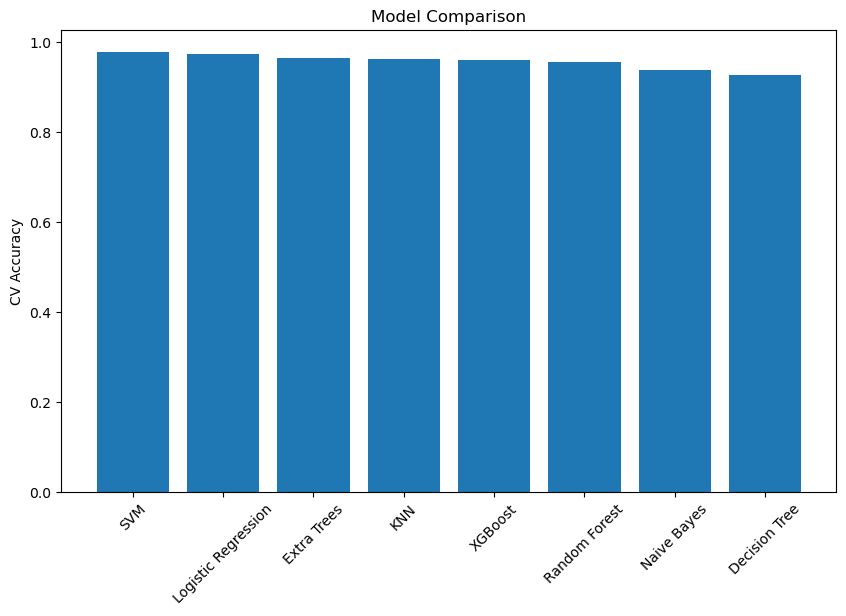

In [17]:
plt.figure(figsize=(10,6))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xticks(rotation=45)
plt.ylabel("CV Accuracy")
plt.title("Model Comparison")
plt.show()

 ## Final Recommendation

## Typical Expected Ranking

Usually:

1. XGBoost
2. Extra Trees
3. Random Forest
4. SVM
5. Logistic Regression
6. Naive Bayes
7. KNN
8. Decision Tree

(KMeans excluded because clustering)

### Best Model Recommendation

#### XGBoost is usually best because:

- strongest bias-variance balance
- boosting corrects previous errors
- regularization prevents overfit
- excellent tabular accuracy



## Practical Recommendation

### If explainability needed:

- Use Logistic Regression / Decision Tree

### If strong production baseline:

- Use Random Forest / Extra Trees

### If best leaderboard score:

- Use XGBoost